# 02 · EDA, Feature Engineering and Customer Segmentation

**Inputs:** the point-in-time feature table built in SQL (`customer_features(cutoff)`, 33 features, see
[`reports/feature_dictionary.md`](../reports/feature_dictionary.md)) and the segmentation fitted by
`python -m src.segmentation`.

**Language rule:** everything below describes *observed behaviour* and *statistical association*.
Nothing here is a causal claim, and no segment name implies anything about a customer's personality or motives.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

from src.config import path
from src.db import connect
from src.features import LABEL, MODEL_FEATURES
from src.preprocess import skew_report

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
FIG = path("reports_dir") / "figures"
con = connect(read_only=True)
train = con.execute("SELECT * FROM marts.model_frame WHERE split = 'train'").df()
snap = con.execute("SELECT * FROM marts.customer_snapshot_current").df()
print(f"train rows (customer x cutoff): {len(train):,} | active customers now: {len(snap):,} | features: {len(MODEL_FEATURES)}")

train rows (customer x cutoff): 36,446 | active customers now: 4,261 | features: 33


## 1 · Target balance and seasonality across cutoffs

,split,cutoff_date,customers,positive_rate_pct
0,train,2010-06-01,2684,49.7
1,train,2010-07-01,2951,48.9
2,train,2010-08-01,3136,54.4
3,train,2010-09-01,3299,58.3
4,train,2010-10-01,3538,53.4
5,train,2010-11-01,3913,44.3
6,train,2010-12-01,4239,33.2
7,train,2011-01-01,4205,33.1
8,train,2011-02-01,4221,34.6
9,train,2011-03-01,4260,36.9


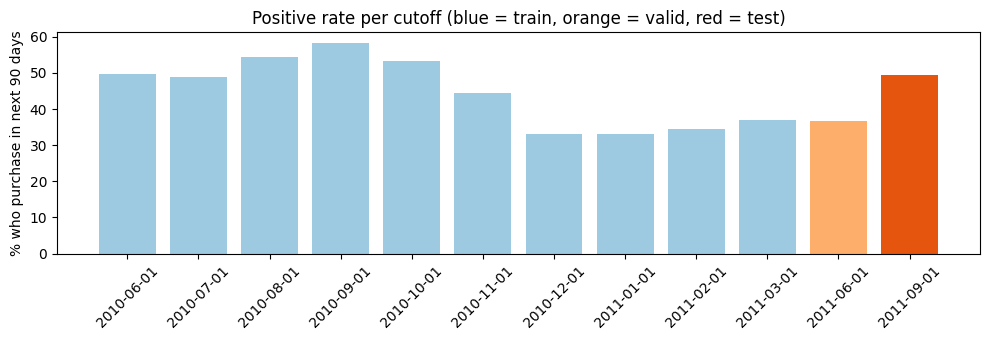

Range 33.1% to 58.3%: no severe imbalance, so no resampling. Windows covering Sep-Nov are higher, a seasonal effect the model must handle.


In [2]:
bal = con.execute(f'''
    SELECT split, cutoff_date, COUNT(*) AS customers, ROUND(100 * AVG({LABEL}), 1) AS positive_rate_pct
    FROM marts.model_frame GROUP BY split, cutoff_date ORDER BY cutoff_date''').df()
display(bal)
fig, ax = plt.subplots(figsize=(10, 3.5))
colors = bal["split"].map({"train": "#9ecae1", "valid": "#fdae6b", "test": "#e6550d"})
ax.bar(bal["cutoff_date"].astype(str), bal["positive_rate_pct"], color=colors)
ax.set_ylabel("% who purchase in next 90 days"); ax.tick_params(axis="x", rotation=45)
ax.set_title("Positive rate per cutoff (blue = train, orange = valid, red = test)")
plt.tight_layout(); plt.savefig(FIG / "eda_positive_rate_by_cutoff.png", dpi=120); plt.show()
print(f"Range {bal['positive_rate_pct'].min()}% to {bal['positive_rate_pct'].max()}%: no severe imbalance, "
      "so no resampling. Windows covering Sep-Nov are higher, a seasonal effect the model must handle.")

## 2 · Why a 90-day horizon?

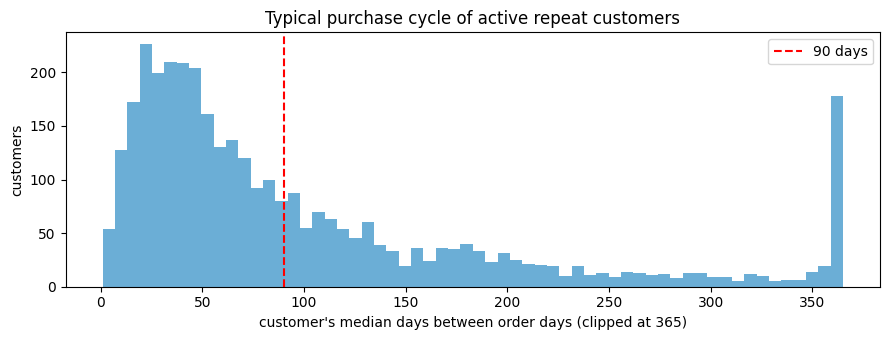

62.4% of repeat customers have a median purchase cycle of <= 90 days (median cycle 64 days). A 90-day window is long enough to observe a typical re-purchase, yet short enough to be actionable.


In [3]:
gaps = snap["median_gap_days"].dropna()
share90 = (gaps <= 90).mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(gaps.clip(upper=365), bins=60, color="#6baed6")
ax.axvline(90, color="red", linestyle="--", label="90 days")
ax.set_xlabel("customer's median days between order days (clipped at 365)"); ax.set_ylabel("customers"); ax.legend()
ax.set_title("Typical purchase cycle of active repeat customers")
plt.tight_layout(); plt.savefig(FIG / "eda_purchase_cycle.png", dpi=120); plt.show()
print(f"{share90:.1f}% of repeat customers have a median purchase cycle of <= 90 days "
      f"(median cycle {gaps.median():.0f} days). A 90-day window is long enough to observe a typical "
      f"re-purchase, yet short enough to be actionable.")

## 3 · Skew: why log-transform?

,feature,skew_raw,skew_log1p
0,recency_days,1.24,-0.33
1,tenure_days,-0.34,-1.59
2,frequency_total,10.93,0.77
3,frequency_365d,11.62,1.22
4,frequency_90d,13.77,0.73
5,gross_spend_total,22.01,0.20
6,gross_spend_365d,19.31,0.39
7,gross_spend_90d,25.55,-0.48
8,aov_365d,41.11,0.26
9,median_order_value,56.03,0.02


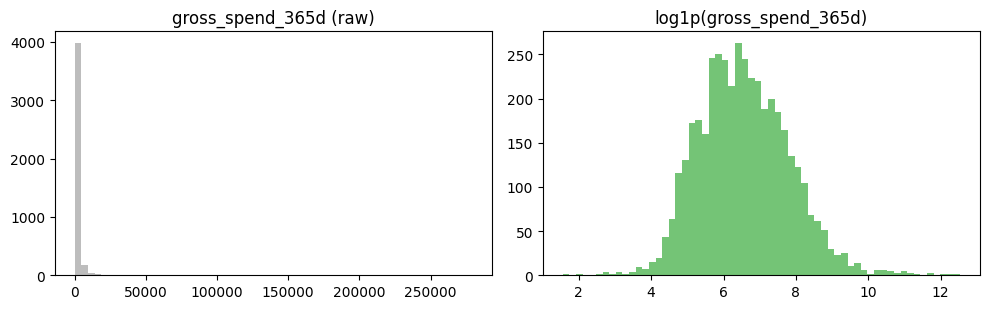

Median |skew| drops from 16.4 to 0.4 after log1p.


In [4]:
sk = skew_report(snap, MODEL_FEATURES)
display(sk)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(snap["gross_spend_365d"], bins=60, color="#bdbdbd"); axes[0].set_title("gross_spend_365d (raw)")
axes[1].hist(np.log1p(snap["gross_spend_365d"].clip(lower=0)), bins=60, color="#74c476"); axes[1].set_title("log1p(gross_spend_365d)")
plt.tight_layout(); plt.savefig(FIG / "eda_log_transform.png", dpi=120); plt.show()
print(f"Median |skew| drops from {sk['skew_raw'].abs().median():.1f} to {sk['skew_log1p'].abs().median():.1f} after log1p.")

## 4 · Missing values

In [5]:
miss = (train[MODEL_FEATURES].isna().mean() * 100).round(1)
display(miss[miss > 0].sort_values(ascending=False).to_frame("pct_missing"))
print("Missing values are structural (e.g. gap statistics need >= 2 or 3 distinct order days), not data errors. "
      "LightGBM handles them natively; linear models and clustering use median imputation fitted on train only.")

,pct_missing
gap_cv,57.6
mean_gap_days,37.5
median_gap_days,37.5
overdue_ratio,37.5
spend_slope_rel_12m,0.2


Missing values are structural (e.g. gap statistics need >= 2 or 3 distinct order days), not data errors. LightGBM handles them natively; linear models and clustering use median imputation fitted on train only.


## 5 · Redundancy between features

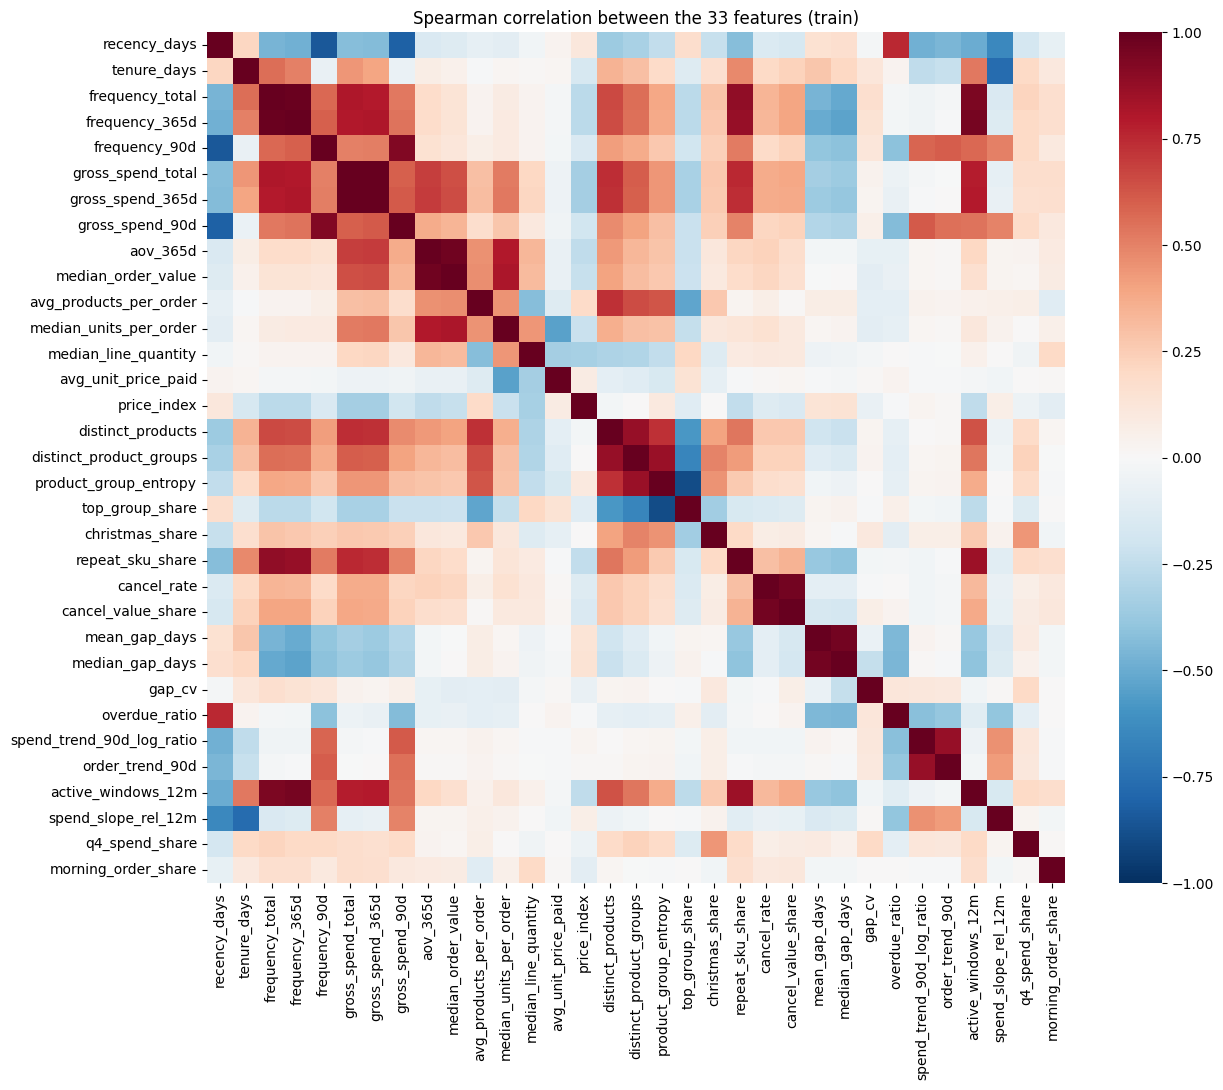

,level_0,level_1,rho
150,gross_spend_total,gross_spend_365d,0.992330
63,frequency_total,frequency_365d,0.986333
228,aov_365d,median_order_value,0.970258
462,cancel_rate,cancel_value_share,0.963193
483,mean_gap_days,median_gap_days,0.962505
118,frequency_365d,active_windows_12m,0.954149
89,frequency_total,active_windows_12m,0.942430
124,frequency_90d,gross_spend_90d,0.925859


Highly correlated pairs share SHAP credit in Step 7, so importance is also reported by feature family.


In [6]:
corr = train[MODEL_FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation between the 33 features (train)")
plt.tight_layout(); plt.savefig(FIG / "eda_feature_correlation.png", dpi=110); plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
             .rename("rho").reset_index().query("abs(rho) >= 0.9").sort_values("rho", ascending=False))
display(pairs)
print("Highly correlated pairs share SHAP credit in Step 7, so importance is also reported by feature family.")

## 6 · Which behaviours are associated with purchasing in the next 90 days? (train, association only)

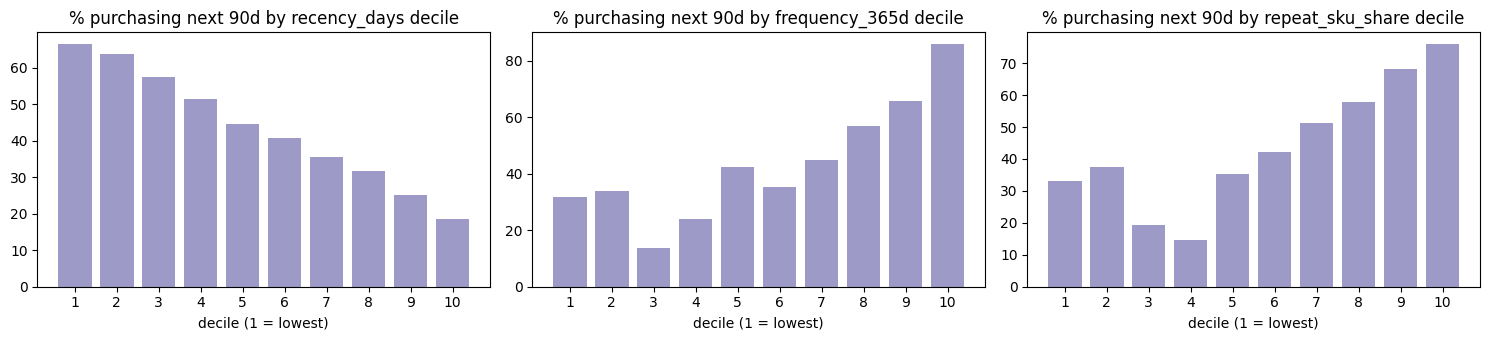

Recent, frequent and re-ordering customers are far more likely to purchase again. These are associations in historical data, not effects of any intervention.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, feat in zip(axes, ["recency_days", "frequency_365d", "repeat_sku_share"]):
    bins = pd.qcut(train[feat].rank(method="first"), 10, labels=range(1, 11))
    rate = train.groupby(bins, observed=True)[LABEL].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color="#9e9ac8")
    ax.set_title(f"% purchasing next 90d by {feat} decile"); ax.set_xlabel("decile (1 = lowest)")
plt.tight_layout(); plt.savefig(FIG / "eda_label_by_decile.png", dpi=120); plt.show()
print("Recent, frequent and re-ordering customers are far more likely to purchase again. These are associations "
      "in historical data, not effects of any intervention.")

## 7 · Segmentation: K-Means vs Gaussian Mixture

,method,k,silhouette,davies_bouldin,calinski_harabasz,bic,min_cluster_share,stability_ari
0,kmeans,2,0.227,1.580,1365.888,NaN,0.367,0.962
1,gmm,2,0.169,2.040,879.517,66429.243,0.427,0.937
2,kmeans,3,0.202,1.679,1161.470,NaN,0.292,0.959
3,gmm,3,0.104,2.147,628.611,53108.827,0.156,0.719
4,kmeans,4,0.196,1.643,1002.012,NaN,0.118,0.899
5,gmm,4,0.091,3.099,443.649,28248.895,0.128,0.694
6,kmeans,5,0.204,1.471,922.299,NaN,0.027,0.875
7,gmm,5,0.085,2.502,524.385,25794.254,0.104,0.872
8,kmeans,6,0.184,1.504,877.902,NaN,0.026,0.898
9,gmm,6,0.070,2.426,484.468,29393.638,0.050,0.671


**Chosen:** `kmeans` with **k = 5** (set manually in config.yaml).  
**HDBSCAN diagnostic:** 3 dense clusters, 83.9% noise.

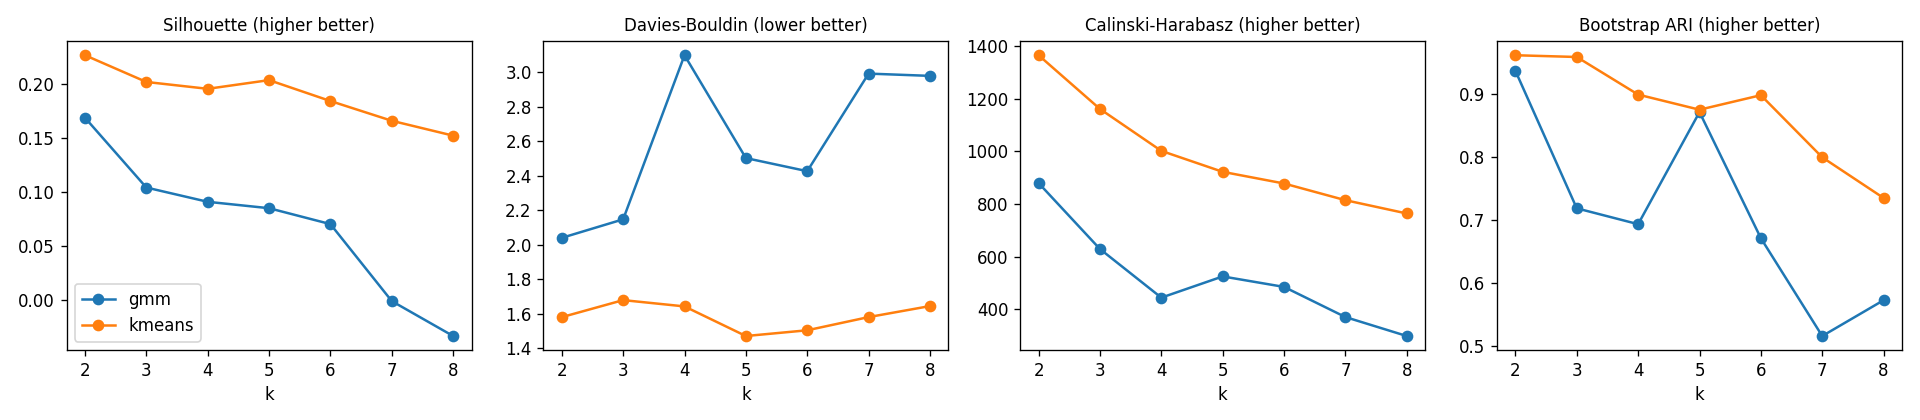

In [8]:
seg = json.loads((path("models_dir") / "segments.json").read_text(encoding="utf-8"))
metrics = pd.DataFrame(seg["metrics"])
display(metrics.round(3))
display(Markdown(f"**Chosen:** `{seg['method']}` with **k = {seg['k']}** ({seg['selection_reason']}).  \n"
                 f"**HDBSCAN diagnostic:** {seg['hdbscan_diagnostic']['n_clusters']} dense clusters, "
                 f"{100 * seg['hdbscan_diagnostic']['noise_share']:.1f}% noise."))
display(Image(filename=str(FIG / "seg_metrics.png")))

**How k was chosen:** each metric measures something different. Silhouette and Davies-Bouldin measure separation,
Calinski-Harabasz measures between/within variance, and bootstrap ARI measures whether the same segments reappear
when the data is resampled. Candidates must be stable (ARI ≥ 0.75) with no segment under 3% of customers; among
those, the best combined rank wins, and ties go to the smaller k because fewer segments are easier to act on.
Customer data rarely has sharply separated groups, so silhouette values are modest. That is normal, and it is
why stability and interpretability carry weight.

## 8 · Segment profiles

,segment_name,n_customers,pct_customers,pct_revenue_365d,recency_days,frequency_365d,gross_spend_365d,aov_365d,median_line_quantity,distinct_products,product_group_entropy,repeat_sku_share,cancel_value_share,spend_trend_90d_log_ratio,active_windows_12m,q4_spend_share,tenure_days,frequency_total,gross_spend_total,median_gap_days
0,Low-spend occasional buyers,487,11.4,2.5,106.0,1.0,183.44,145.05,12.0,7.0,0.687,0.0,0.0,0.0,1.0,0.135,262.0,2.0,256.32,103.5
1,Recent seasonal buyers,1354,31.8,12.3,27.0,2.0,598.055,289.94,6.0,58.0,1.76,0.101,0.0,5.85,2.0,0.662,403.0,3.0,981.63,96.0
2,Core high-value repeat accounts,1071,25.1,72.0,17.0,7.0,2740.03,365.793,10.0,162.0,1.786,0.407,0.009,0.434,6.0,0.337,656.0,13.0,5032.22,37.0
3,Lapsed buyers,1234,29.0,8.6,173.0,1.0,408.475,270.274,6.0,47.0,1.637,0.095,0.0,0.0,1.0,0.0,488.0,3.0,870.56,91.0
4,High-cancellation accounts,115,2.7,4.6,79.0,2.0,450.3,245.308,10.0,25.0,1.429,0.107,0.243,0.0,2.0,0.273,442.0,3.0,908.35,97.0


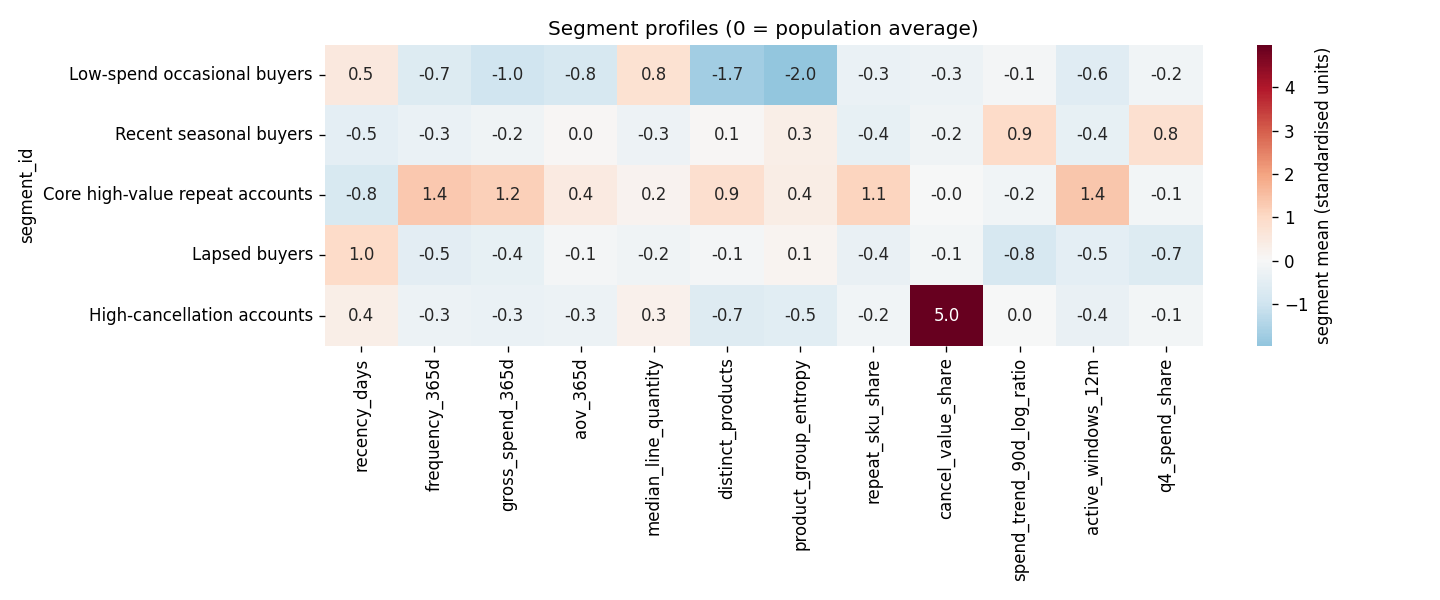

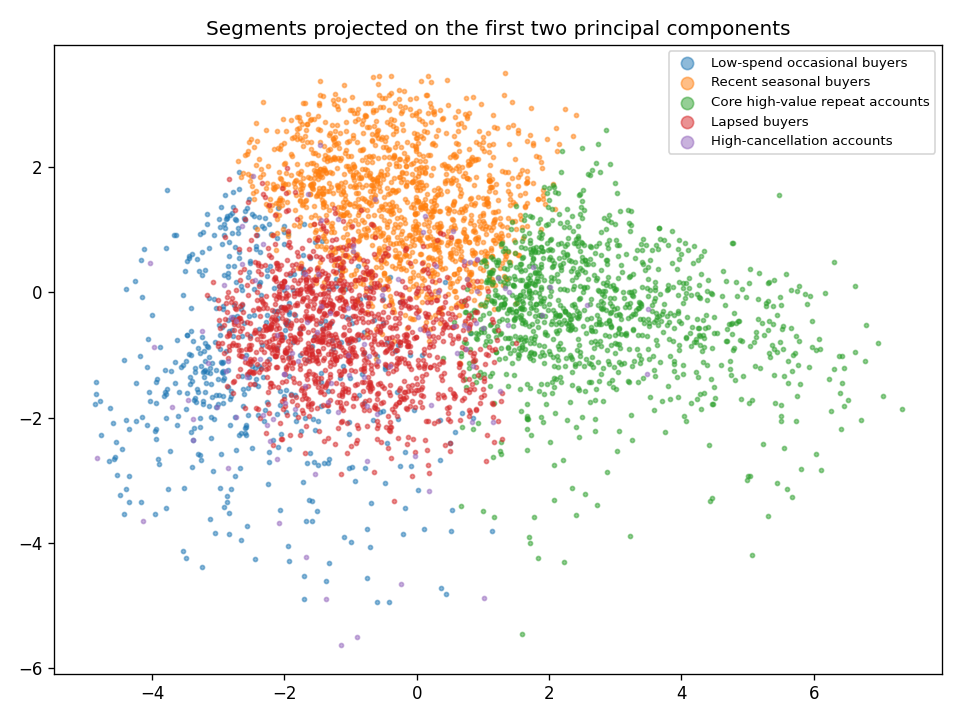

In [9]:
prof = pd.DataFrame(seg["profiles"]).T
display(prof)
display(Image(filename=str(FIG / "seg_profile_heatmap.png")))
display(Image(filename=str(FIG / "seg_pca.png")))

## 9 · Audit: segment mix by market (country is not a clustering input)

In [10]:
seg_tbl = con.execute("SELECT * FROM marts.customer_segments").df()
aud = snap[["customer_id", "country"]].merge(seg_tbl, on="customer_id")
aud["market"] = np.where(aud["country"] == "United Kingdom", "UK", "International")
display((pd.crosstab(aud["segment_name"], aud["market"], normalize="columns") * 100).round(1))

market,International,UK
segment_name,,
Core high-value repeat accounts,28.8,24.7
High-cancellation accounts,3.7,2.6
Lapsed buyers,30.2,28.8
Low-spend occasional buyers,9.5,11.6
Recent seasonal buyers,27.8,32.2


In [11]:
con.close()